In [1]:
from tensorflow.keras.datasets.mnist import load_data

(x_train, y_train), (x_test, y_test) = load_data(path='mnist.npz')

In [2]:
# 학습 데이터
print(x_train.shape, y_train.shape)
print(y_train)

(60000, 28, 28) (60000,)
[5 0 4 ... 5 6 8]


In [3]:
# 테스트 데이터
print(x_test.shape, y_test.shape)
print(y_test)

(10000, 28, 28) (10000,)
[7 2 1 ... 4 5 6]


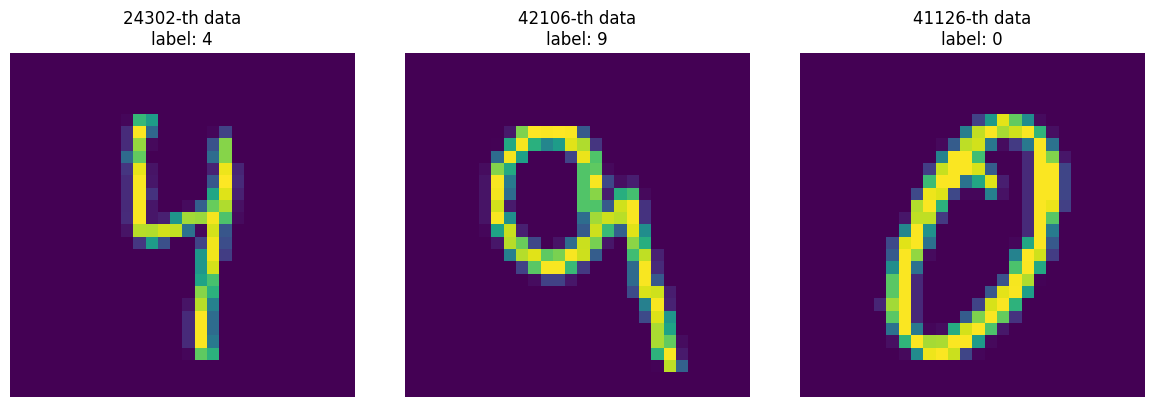

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sample_size = 3
random_idx = np.random.randint(60000, size=sample_size)

fig, axes = plt.subplots(1, sample_size, figsize=(12, 4))

for i, idx in enumerate(random_idx):
    img = x_train[idx, :]
    label = y_train[idx]
    
    axes[i].imshow(img)
    axes[i].set_title(f'{idx}-th data\nlabel: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### 검증 데이터 만들기

In [5]:
from sklearn.model_selection import train_test_split

# 훈련/테스트 데이터를 0.7 / 0.3의 비율로 분리
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=777)

print(f'훈련 데이터 {x_train.shape} 레이블 {y_train.shape}')
print(f'검증 데이터 {x_val.shape} 레이블 {y_val.shape}')

훈련 데이터 (42000, 28, 28) 레이블 (42000,)
검증 데이터 (18000, 28, 28) 레이블 (18000,)


#### 모델 입력을 위한 데이터 전처리

In [6]:
num_x_train = x_train.shape[0]
num_x_val = x_val.shape[0]
num_x_test = x_test.shape[0]

# 모델의 입력으로 사용하기 위한 전처리
x_train = (x_train.reshape((num_x_train, 28*28))) / 255
x_val = (x_val.reshape((num_x_val, 28*28))) / 255
x_test = (x_test.reshape((num_x_test, 28*28))) / 255

print(x_train.shape)

(42000, 784)


#### 모델 입력을 위한 레이블 전처리

In [7]:
from tensorflow.keras.utils import to_categorical

# 각 데이터의 레이블을 범주형 형태로 변경
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print(y_train)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


#### 모델 구성하기

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
# 입력 데이터의 형태를 꼭 명시
# 784차원의 데이터를 입력으로 받고, 64개의 출력을 가지는 첫번째 Dense층
model.add(Input(shape=(784, )))
model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))

#### 학습과정 설정하기

In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['acc'])

#### 모델 학습하기

In [10]:
history = model.fit(x_train, y_train,
                    epochs = 30,
                    batch_size = 128,
                    validation_data = (x_val, y_val))

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8612 - loss: 0.4823 - val_acc: 0.9232 - val_loss: 0.2695
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9378 - loss: 0.2134 - val_acc: 0.9446 - val_loss: 0.1908
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9528 - loss: 0.1577 - val_acc: 0.9509 - val_loss: 0.1676
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9623 - loss: 0.1282 - val_acc: 0.9573 - val_loss: 0.1427
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9694 - loss: 0.1057 - val_acc: 0.9591 - val_loss: 0.1355
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9736 - loss: 0.0895 - val_acc: 0.9604 - val_loss: 0.1266
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9762 - loss: 0.0783 - val_acc: 0.9634 - val_loss: 0.1209
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9800 - loss: 0.0685 - val_acc: 0.9601 - val_loss: 0.1335
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ac

#### history를 통해 확인해볼 수 있는 값 출력하기

In [11]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

#### 학습 결과 그려보기

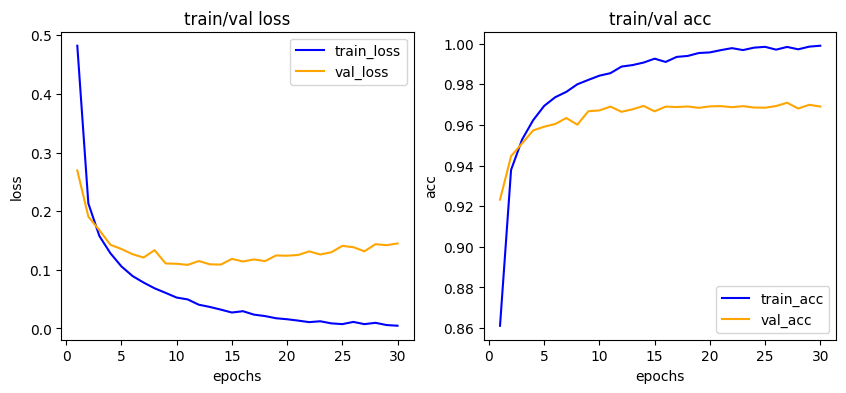

In [12]:
his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss'] # 검증 데이터가 있는 경우 val_ 수식어가 붙음

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 4))

# 학습 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='orange', label='val_loss')
ax1.set_title('train/val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 학습 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='train_acc')
ax2.plot(epochs, val_acc, color='orange', label='val_acc')
ax2.set_title('train/val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

#### 모델 평가하기

In [13]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9741 - loss: 0.1261


[0.12609218060970306, 0.9740999937057495]

#### 학습된 모델을 통해 값 예측하기

In [14]:
results = model.predict(x_test)

print("예측 결과 shape:", results.shape)

first_result = results[0]
pred_class = np.argmax(first_result)

print("\n[첫 번째 테스트 데이터의 클래스별 확률]")
for i, prob in enumerate(first_result):
    print(f"클래스 {i}: {prob*100:6.2f}%")

print(f"\n예측한 클래스: {pred_class}")

second_result = results[1]
pred_class = np.argmax(second_result)

print("\n[두 번째 테스트 데이터의 클래스별 확률]")
for i, prob in enumerate(second_result):
    print(f"클래스 {i}: {prob*100:6.2f}%")

print(f"\n예측한 클래스: {pred_class}")

third_result = results[2]
pred_class = np.argmax(third_result)

print("\n[세 번째 테스트 데이터의 클래스별 확률]")
for i, prob in enumerate(third_result):
    print(f"클래스 {i}: {prob*100:6.2f}%")

print(f"\n예측한 클래스: {pred_class}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
예측 결과 shape: (10000, 10)

[첫 번째 테스트 데이터의 클래스별 확률]
클래스 0:   0.00%
클래스 1:   0.00%
클래스 2:   0.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.00%
클래스 7: 100.00%
클래스 8:   0.00%
클래스 9:   0.00%

예측한 클래스: 7

[두 번째 테스트 데이터의 클래스별 확률]
클래스 0:   0.00%
클래스 1:   0.00%
클래스 2: 100.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.00%
클래스 7:   0.00%
클래스 8:   0.00%
클래스 9:   0.00%

예측한 클래스: 2

[세 번째 테스트 데이터의 클래스별 확률]
클래스 0:   0.00%
클래스 1:  99.96%
클래스 2:   0.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.00%
클래스 7:   0.04%
클래스 8:   0.00%
클래스 9:   0.00%

예측한 클래스: 1


#### 예측값 그려서 확인해보기

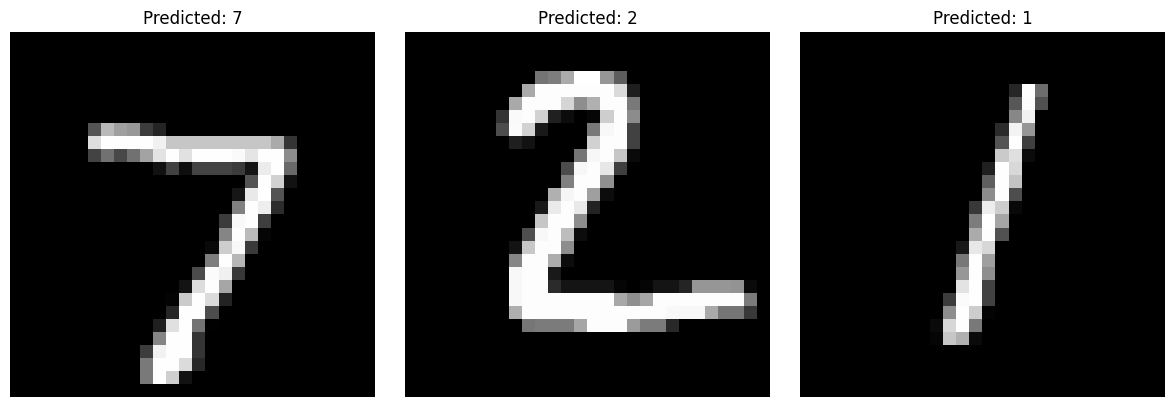

In [15]:
arg_results = np.argmax(results, axis=-1)

sample_size = 3

fig, axes = plt.subplots(1, sample_size, figsize=(12, 4))

for i in range(sample_size):
    axes[i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Predicted: {arg_results[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

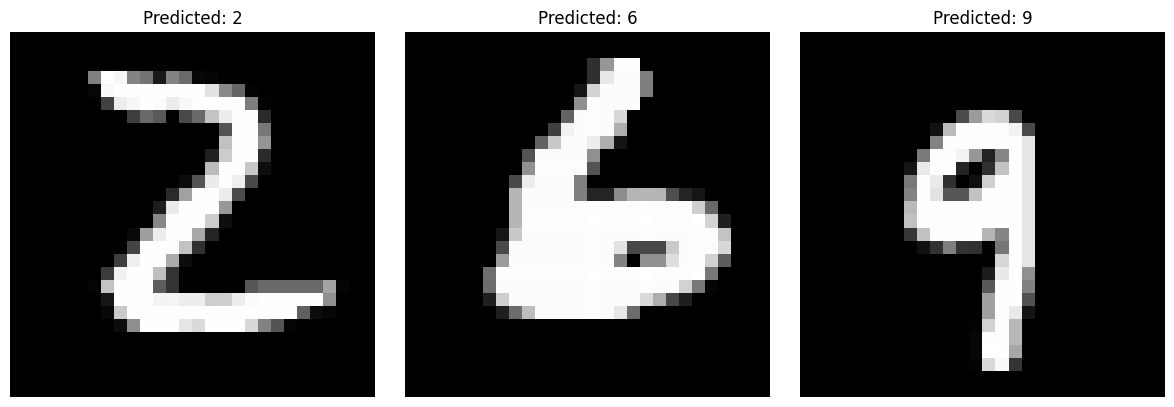

In [16]:
# [랜덤하게]
sample_size = 3
random_idx = np.random.choice(len(x_test), sample_size, replace=False)

fig, axes = plt.subplots(1, sample_size, figsize=(12, 4))

for i, idx in enumerate(random_idx):
    axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Predicted: {arg_results[idx]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()